In [ ]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

In [10]:
tsi = []
sta_awake = []
sta_nrem = []

for mouse_id in MOUSE_IDS:
    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    tsi.append(turn_units['turn_index'])

    sta_awake.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_awake.npz"))
    sta_nrem.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem.npz"))


tsi = np.concatenate(tsi)
order = np.argsort(tsi)
sta_awake = np.rad2deg(np.column_stack(sta_awake))
sta_nrem = np.rad2deg(np.column_stack(sta_nrem))

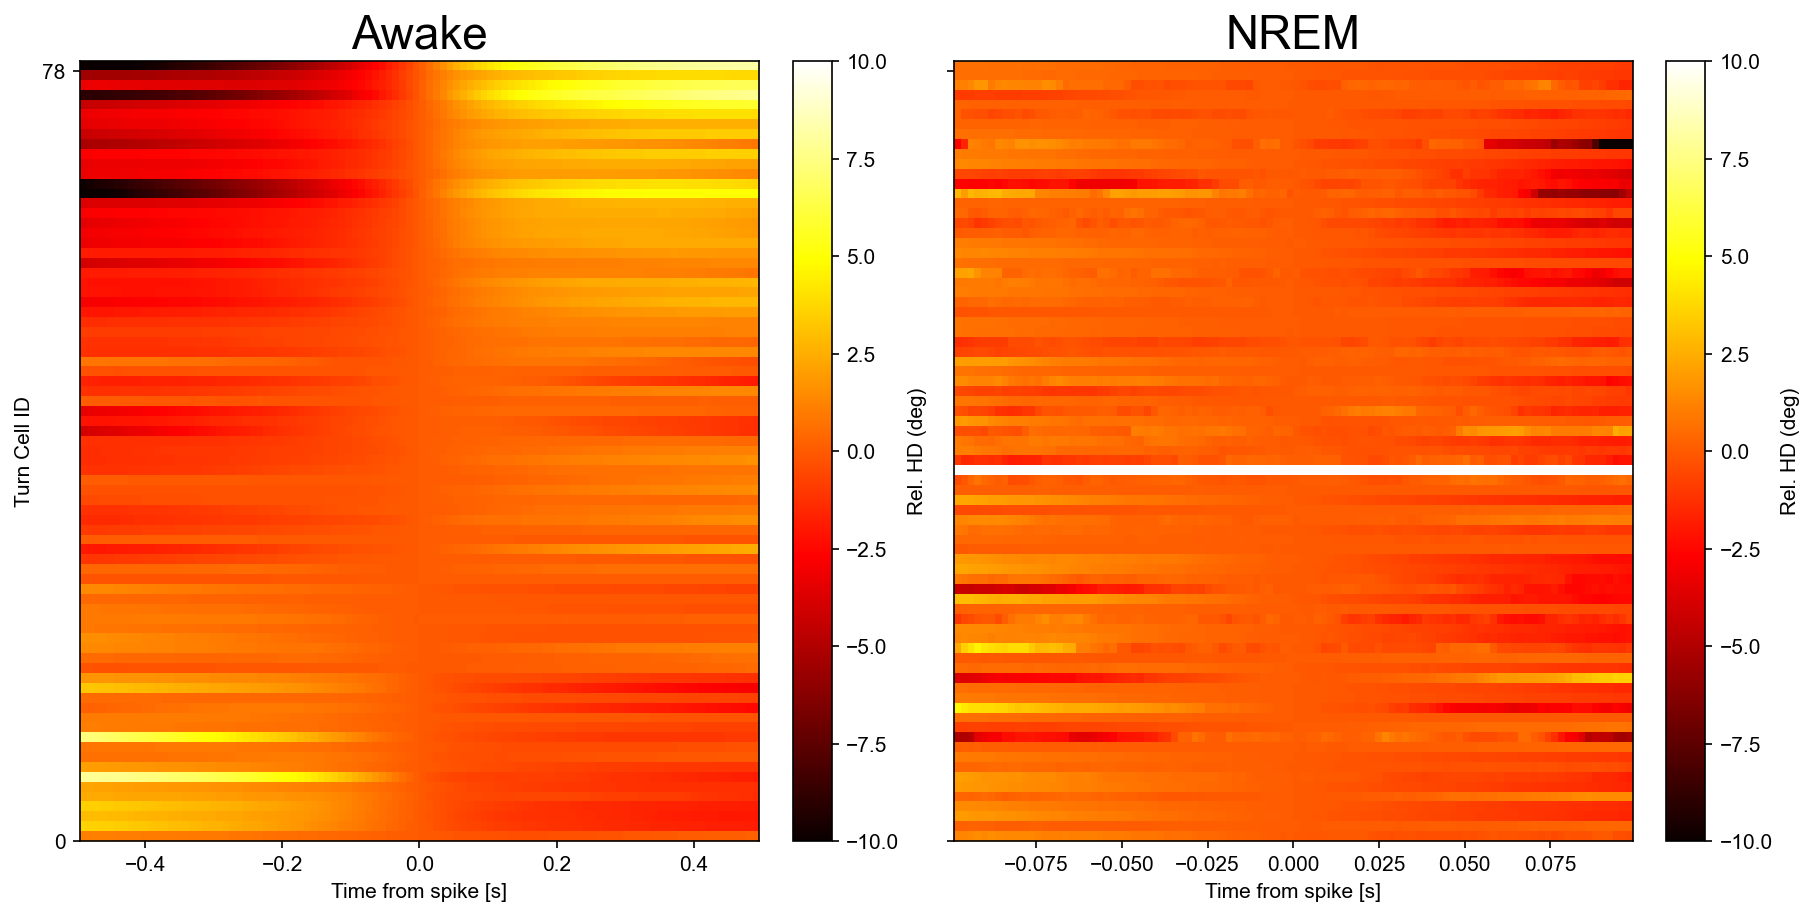

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes = axes.flatten()

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem], ["Awake", "NREM"])):
    im = axes[i].imshow(
        sta[:, order].d.T,
        aspect='auto',
        origin='lower',
        extent=[sta.index[0], sta.index[-1], 0, sta.shape[1]],
        cmap='hot',
        norm=norm,
        )
    
    plt.colorbar(im, ax=axes[i], label='Rel. HD (deg)')
    axes[i].set_title(f"{state}", fontsize=22)
    axes[i].set_xlabel("Time from spike [s]")
    
axes[0].set_ylabel("Turn Cell ID")
axes[0].set_yticks([0, sta.shape[1]-1])
# axes[0].set_xticks([-0.5, 0, 0.5])
# axes[1].set_xticks([-0.2, 0, 0.2])
plt.show()
# plt.savefig(FIGURES_DIR / "sta" /  "mv2st99" / "heatmap_turn.png")

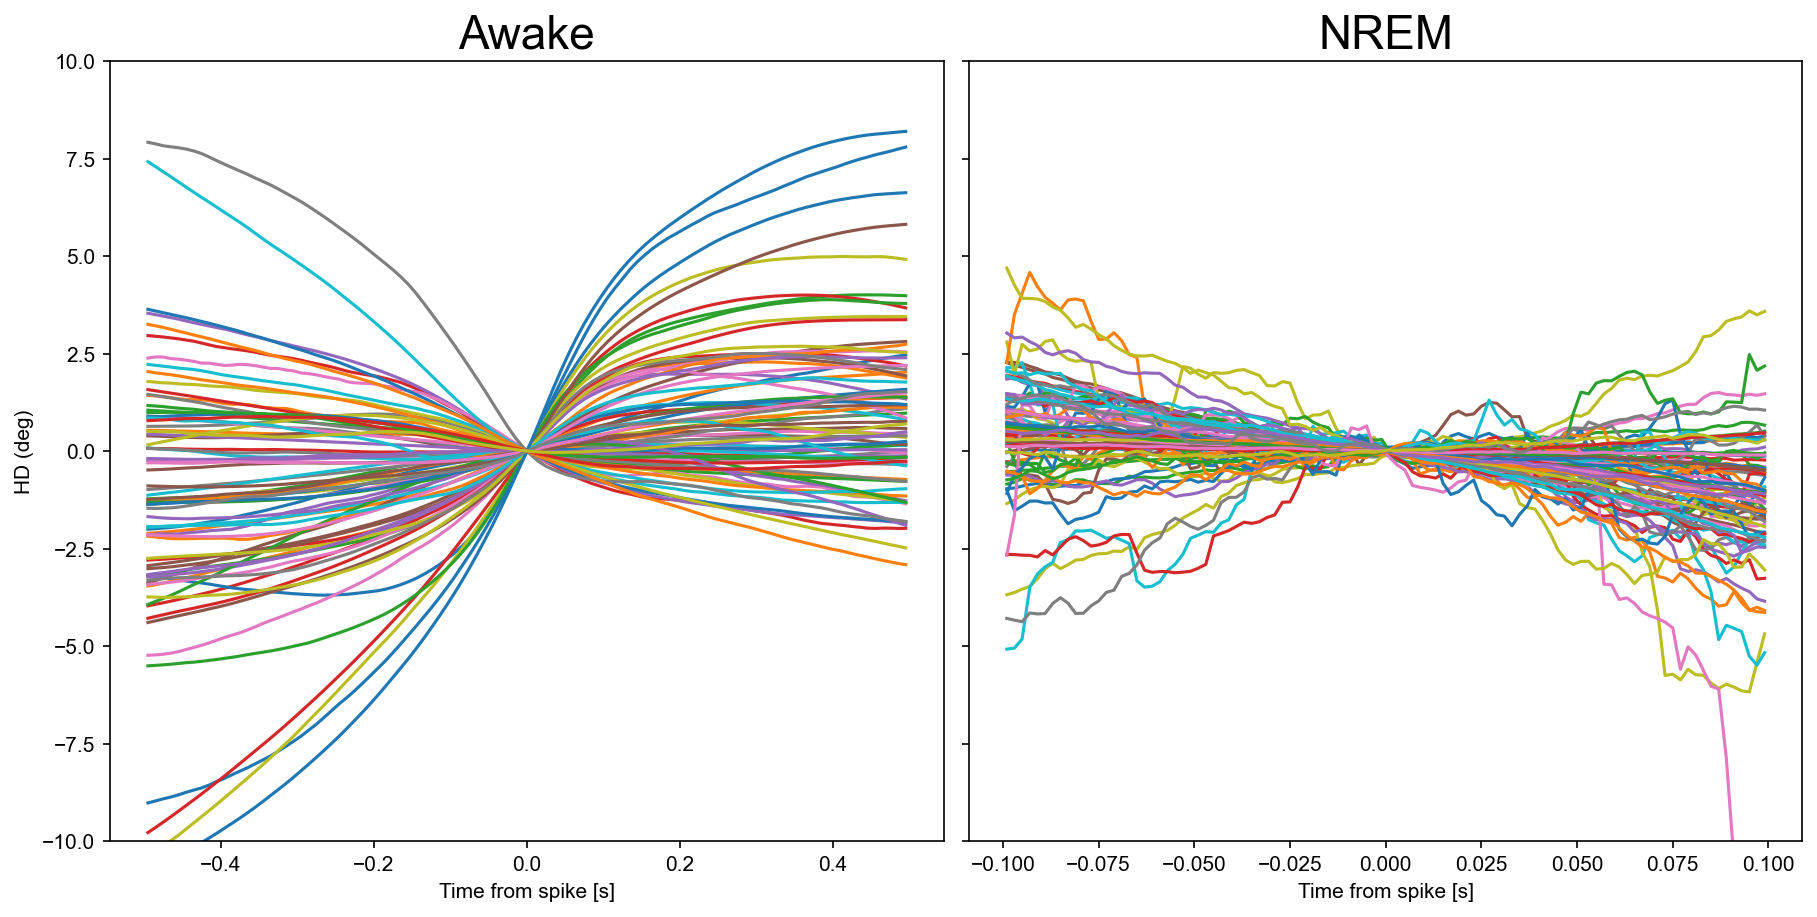

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
axes = axes.flatten()

for i, (sta, state) in enumerate(zip([sta_awake, sta_nrem], ["Awake", "NREM"])):
    axes[i].plot(sta.index, sta)
    axes[i].set_title(f"{state}", fontsize=22)
    axes[i].set_xlabel("Time from spike [s]")
    
axes[0].set_ylabel("HD (deg)")
axes[0].set_ylim([-10, 10])
# axes[0].set_xticks([-0.5, 0, 0.5])
# axes[1].set_xticks([-0.2, 0, 0.2])
plt.show()
# plt.savefig(FIGURES_DIR / "sta" /  "mv2st99" / "heatmap_turn.png")